In [1]:
import matplotlib.pyplot as plt, pandas as pd
import PLOT_SETTINGS as ps, matplotlib.ticker as ticker, ast, os
from matplotlib.lines import Line2D

In [2]:
def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    
    ax.text(0.33, -0.17, r"$x_{\mathrm{CO_2}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")

    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")

    ax.text(0.36, -0.17, r"$y_{\mathrm{CO_2}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")

    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")
    
def set_custom_ylabel(ax, fontsize=ps.label_fontsize):
    
    ax.text(1.12, 0.5, r"Correction term (WSD)", color="blue", fontsize=ps.label_fontsize,
            transform=ax.transAxes, va="center", ha="center",rotation=90)

def save_plot(fig, filename_base, folder="PLOTS"):
    """
    Save a figure as both PNG and PDF using ps.save_figure.
    """
    os.makedirs(folder, exist_ok=True)

    png_path = os.path.join(folder, f"{filename_base}.png")
    pdf_path = os.path.join(folder, f"{filename_base}.pdf")

    ps.save_figure(fig, png_path)
    ps.save_figure(fig, pdf_path)

In [3]:
df_IFT_kij_230  = pd.read_csv(f'surface_tension_kij_253.28k.csv')
Model           = pd.read_csv(f'IFT_P_CO2-Argon_253.csv')

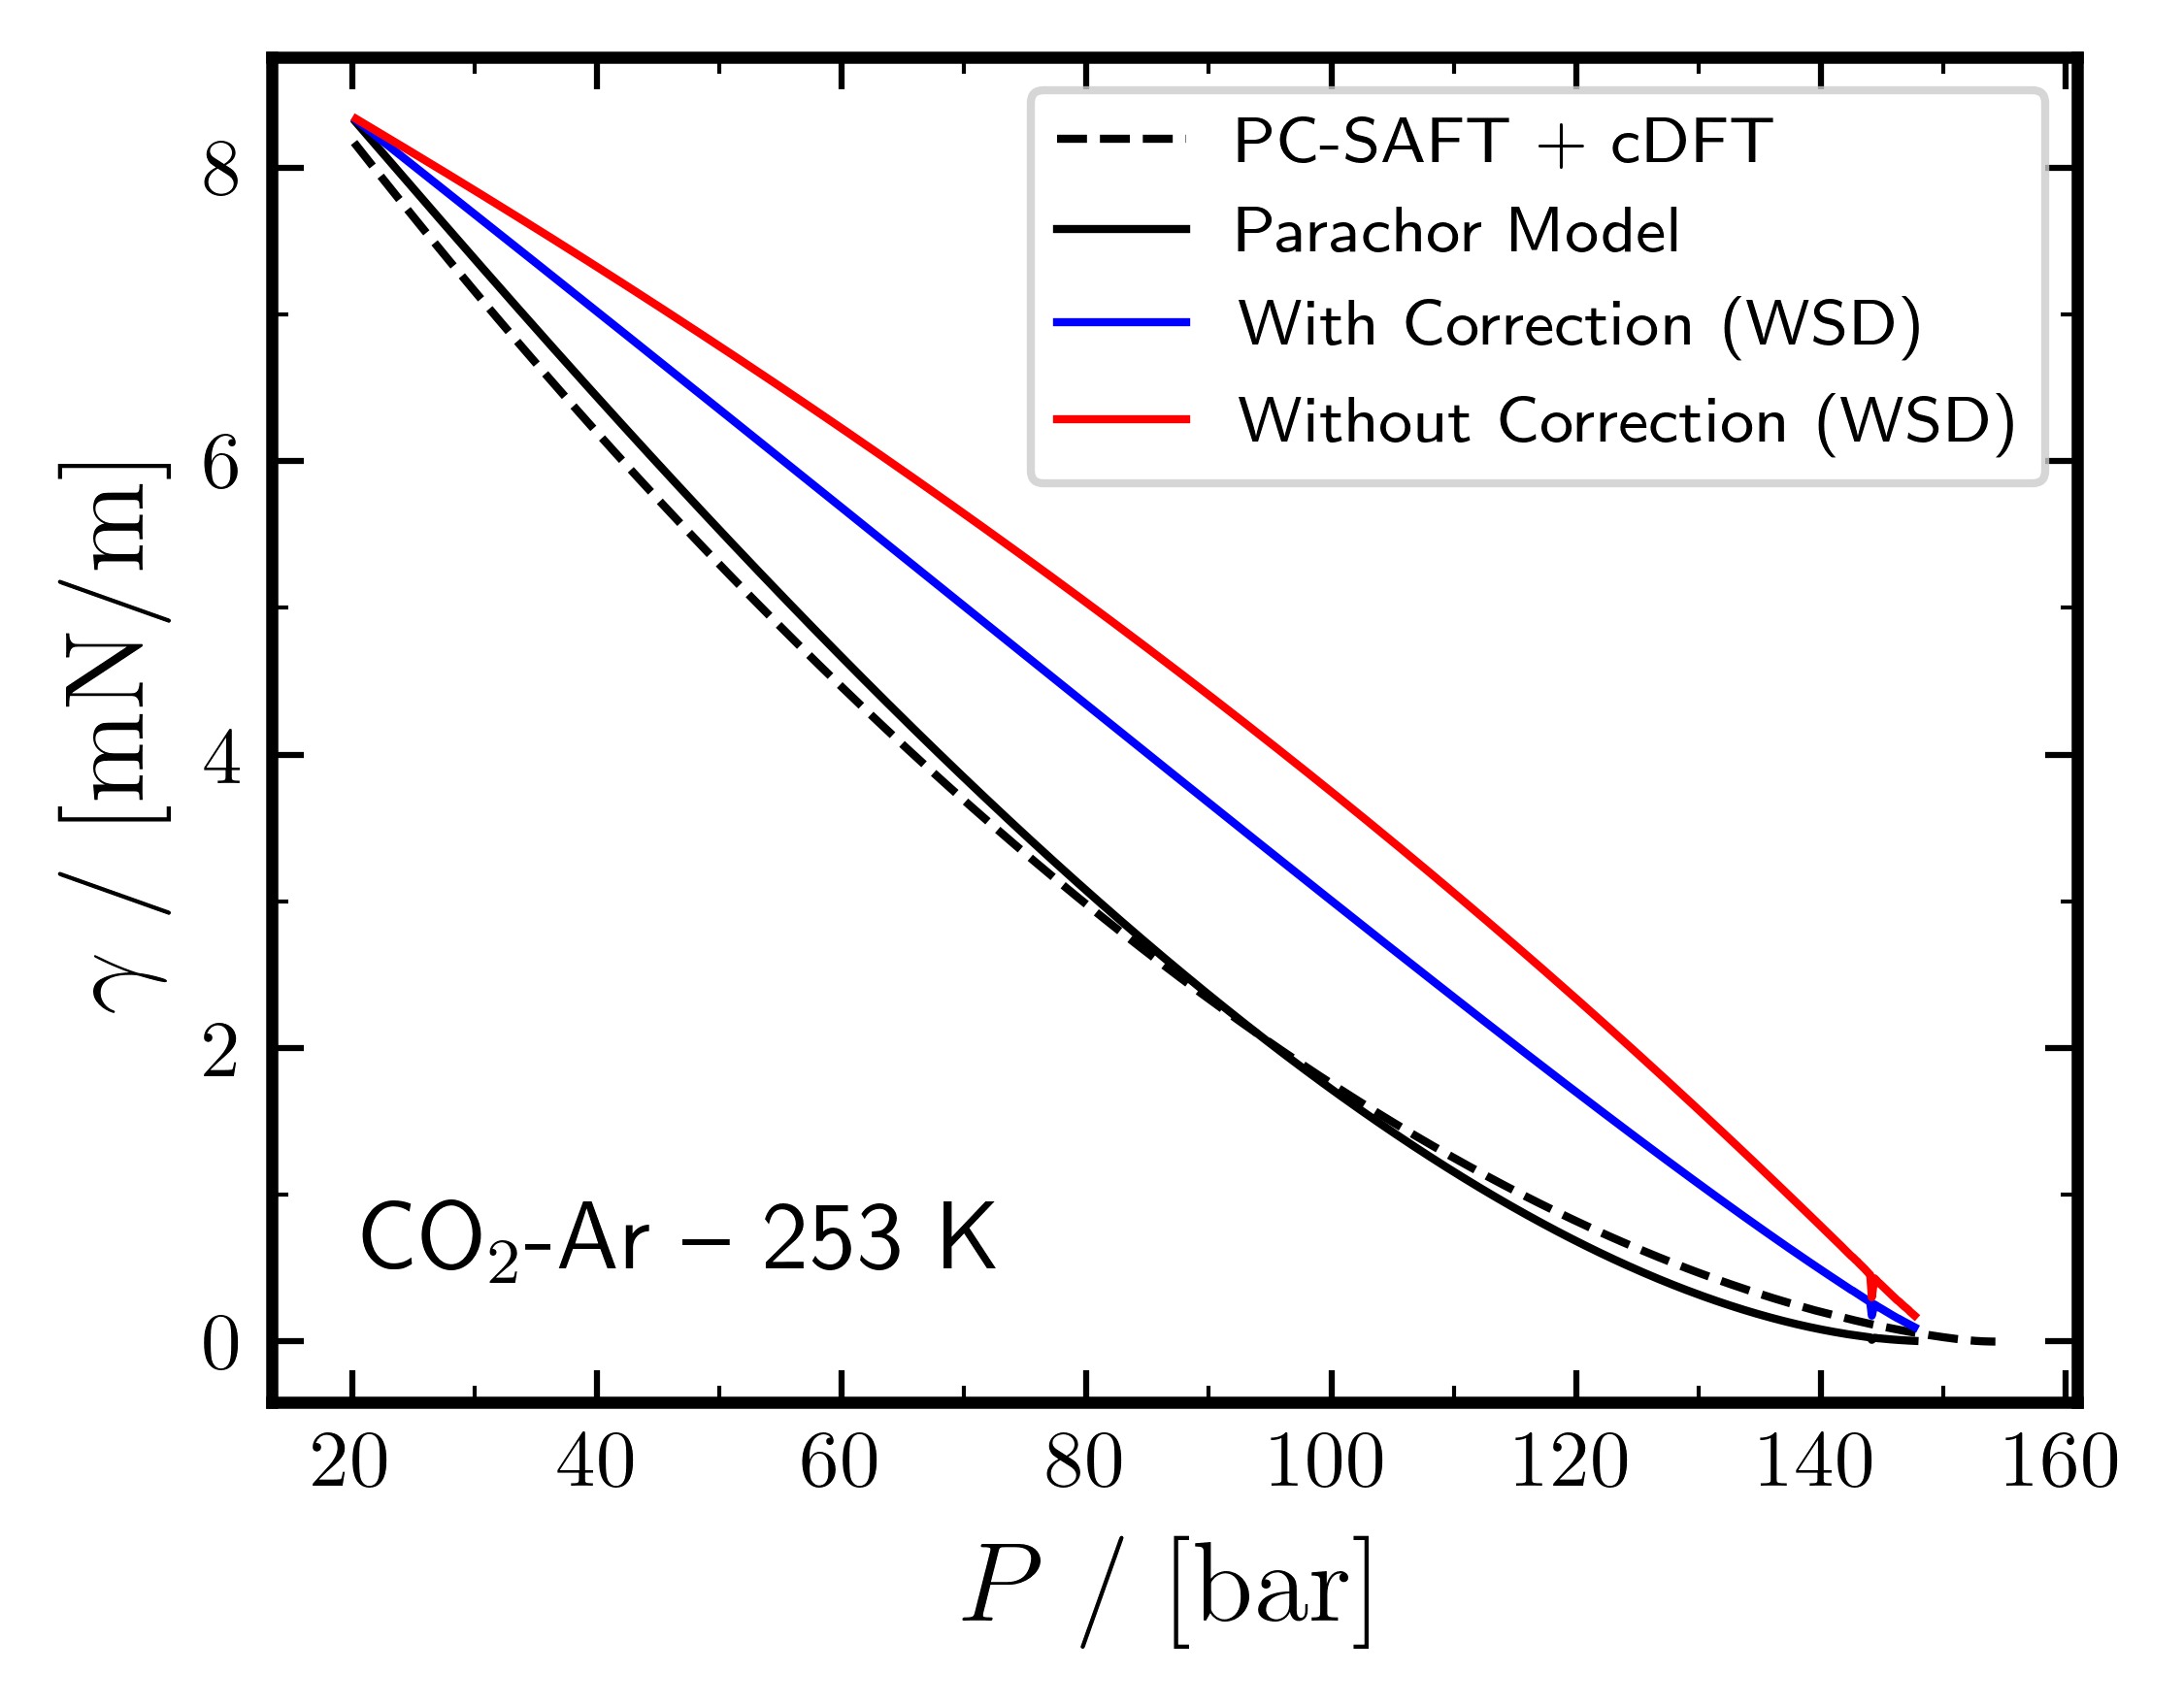

In [4]:
fig2, ax2 = ps.plot_init()

ax2.plot(df_IFT_kij_230['Pressure_[bar]'], df_IFT_kij_230['Surface_Tension_[mN/m]'],
    color='k',linestyle="--",linewidth=ps.linewidth, label='PC-SAFT + cDFT')

ax2.plot(Model['P [bar]'], Model['gamma_Parachor [mN/m]'],
    color='k',linestyle="-",linewidth=ps.linewidth, label='Parachor Model')

ax2.plot(Model['P [bar]'], Model['gamma_WSD [mN/m]'],
    color='blue',linestyle="-",linewidth=ps.linewidth, label='With Correction (WSD)')

ax2.plot(Model['P [bar]'], Model['gamma_WSD [mN/m]']/Model['mixcorr_WSD'],
    color='red',linestyle="-",linewidth=ps.linewidth, label='Without Correction (WSD)')

ax2.minorticks_on()
ax2.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax2.yaxis.set_minor_locator(ticker.MultipleLocator(1))  

ax2.set_xlabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)
ax2.set_ylabel(r'$\gamma \; / \; [\mathrm{mN/m}]$', fontsize=ps.label_fontsize)

plt.text(0.05, 0.15, "CO$_2$-Ar -- 253 K",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top')

ax2.legend(fontsize=ps.legend_fontsize, loc='upper right')
plt.show()
save_plot(fig2, f'IFT_vs_Pressure_CO2_Ar_253K')

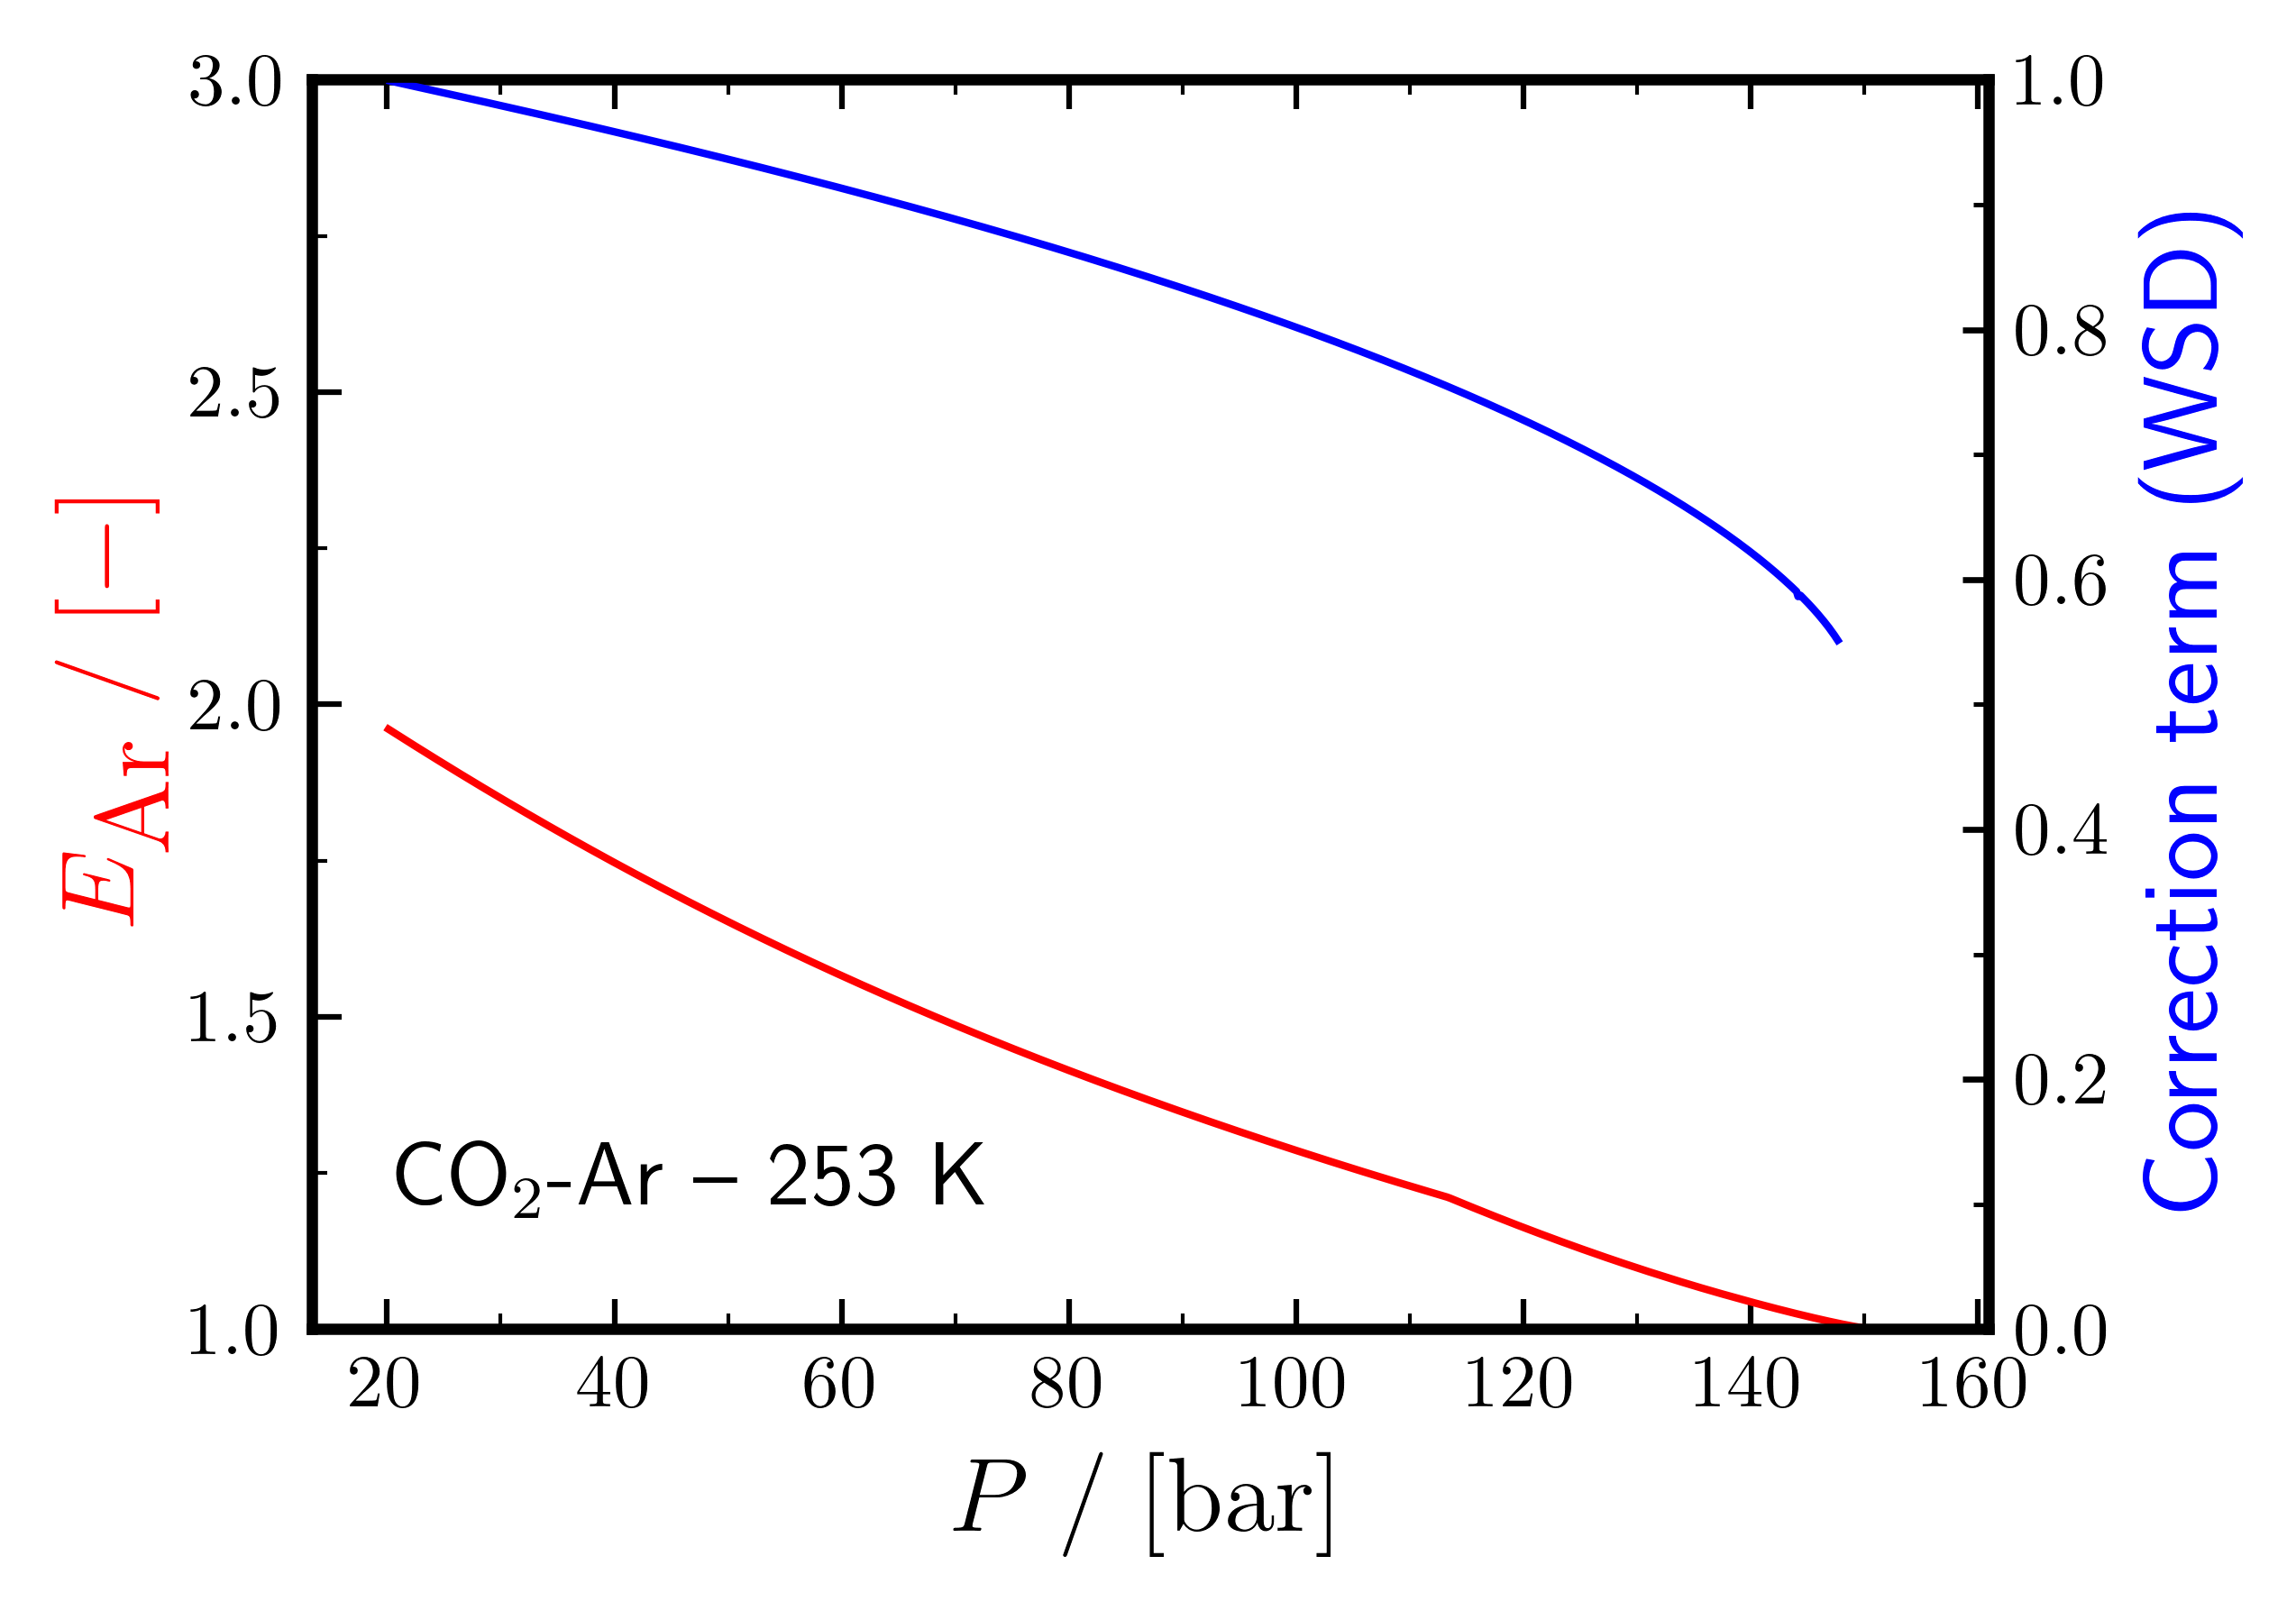

In [5]:
fig1, ax1 = ps.plot_init()
ax1b = ax1.twinx()

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

ax1.plot(df_IFT_kij_230['Pressure_[bar]'], df_IFT_kij_230['Enrichment_AR_[-]'],
    color='red',linestyle="-",linewidth=ps.linewidth)

ax1b.plot(Model['P [bar]'], Model['mixcorr_WSD'],
    color='blue',linestyle="-",linewidth=ps.linewidth)

ax1.minorticks_on()
ax1.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax1.set_xlabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)
ax1b.text(-0.12, 0.5,r'$E_{\textrm{Ar}} \; / \; [-]$',color="red",fontsize=ps.label_fontsize,
         transform=ax1b.transAxes,ha="center",va="center",rotation=90)

ax1b.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1b.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax1b.tick_params(axis='y', which='both', direction='in')

set_custom_ylabel(ax1b, fontsize=ps.label_fontsize)
ax1b.set_ylabel("")

ax1b.set_ylim(0, 1.0)
ax1.set_ylim(1, 3)
ax1b.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.text(0.05, 0.15, "CO$_2$-Ar -- 253 K",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top')

plt.show()
save_plot(fig1, f'Enrichment_vs_correction_CO2_Ar_253K')